In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Base/processed_cell_MR.csv')

def plot_cell_days(df, cell_name, hours_per_day=24):
    series = df[cell_name].values
    n_days = len(series) // hours_per_day
    series = series[:n_days * hours_per_day]          # drop any partial trailing day
    daily = series.reshape(n_days, hours_per_day)      # (n_days, 24)

    fig, ax = plt.subplots(figsize=(10, 6))
    for day_idx in range(n_days):
        ax.plot(range(hours_per_day), daily[day_idx], alpha=0.6, linewidth=1)

    ax.set_xlabel('Hour of day')
    ax.set_ylabel(cell_name)
    ax.set_title(f'{cell_name} — {n_days} overlaid daily profiles')
    ax.set_xticks(range(0, hours_per_day, 2))
    plt.tight_layout()
    plt.show()

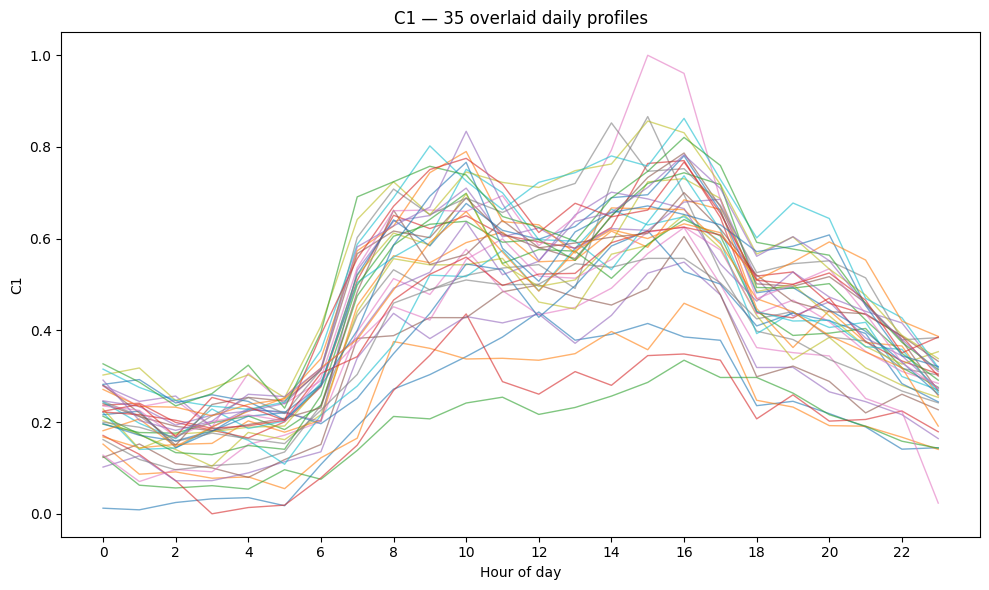

In [18]:
CELL_NAME = 'C1'
plot_cell_days(df, CELL_NAME)

In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv('Base/processed_cell_MR.csv')
HOURS_PER_DAY = 24

def mean_daily_profile(series, hours_per_day=24):
    n_days = len(series) // hours_per_day
    series = series[:n_days * hours_per_day]
    daily = series.reshape(n_days, hours_per_day)
    return daily.mean(axis=0)   # (24,) average day shape

profiles = {}
for cell in df.columns:
    raw = df[cell].values
    mean_profile = mean_daily_profile(raw)
    # normalize shape (0-1) so clustering is based on WHEN peaks happen,
    # not how BIG the cell's traffic is overall
    rng = mean_profile.max() - mean_profile.min()
    norm_profile = (mean_profile - mean_profile.min()) / rng if rng > 0 else mean_profile
    profiles[cell] = norm_profile

profile_df = pd.DataFrame(profiles).T   # rows = cells, cols = hour 0-23
profile_df.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
M1,0.368579,0.174086,0.047432,0.000000,0.004225,0.038468,0.273987,0.664284,0.597060,0.498593,...,0.585993,0.640790,0.826487,0.904851,0.888786,0.942366,1.000000,0.934719,0.803334,0.577616
M2,0.322143,0.188251,0.086483,0.088177,0.000000,0.064192,0.190543,0.349118,0.514163,0.549287,...,0.787694,0.824110,0.928287,0.902994,0.955359,1.000000,0.924949,0.761987,0.668791,0.493015
M3,0.212383,0.116296,0.039311,0.000000,0.046875,0.074208,0.236347,0.335755,0.353106,0.313607,...,0.351399,0.357239,0.414932,0.654261,0.933584,1.000000,0.840827,0.701576,0.583699,0.361304
M4,0.401932,0.261271,0.127323,0.013938,0.007233,0.000000,0.111689,0.336457,0.403314,0.405198,...,0.580395,0.592925,0.674421,0.939539,1.000000,0.936878,0.806020,0.706886,0.615996,0.488901
M5,0.405642,0.255438,0.167253,0.000000,0.055197,0.066418,0.155510,0.153535,0.113131,0.097237,...,0.184448,0.237299,0.370235,0.608387,0.780871,0.912015,1.000000,0.982677,0.870606,0.623419


In [24]:
from sklearn.cluster import KMeans

# only cluster micro cells (C-prefixed), not macros
micro_cells = [c for c in profile_df.index if c.startswith('C')]
X = profile_df.loc[micro_cells].values

k = 4   # business/retail/transport/campus/residential — start here, check silhouette
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

cluster_map = pd.Series(labels, index=micro_cells, name='cluster')
cluster_map.sort_values()

C14    0
C11    0
C34    0
C32    0
C37    0
C35    0
C40    0
C39    0
C41    0
C18    1
C26    1
C22    1
C9     1
C16    1
C4     1
C7     1
C27    1
C24    1
C25    1
C45    1
C42    1
C12    1
C6     1
C5     1
C29    2
C31    2
C23    2
C30    2
C1     2
C3     2
C2     2
C10    3
C28    3
C21    3
C20    3
C17    3
C15    3
C38    3
C43    3
Name: cluster, dtype: int32

In [29]:
# count number of cells in each cluster
cluster_counts = cluster_map.value_counts().sort_index()
cluster_counts

cluster
0     9
1    15
2     7
3     8
Name: count, dtype: int64

In [26]:
from sklearn.metrics import silhouette_score

for k_test in range(2, 9):
    km = KMeans(n_clusters=k_test, random_state=42, n_init=10).fit(X)
    score = silhouette_score(X, km.labels_)
    print(f"k={k_test}: silhouette={score:.3f}")

k=2: silhouette=0.294
k=3: silhouette=0.266
k=4: silhouette=0.257
k=5: silhouette=0.222
k=6: silhouette=0.214
k=7: silhouette=0.195
k=8: silhouette=0.188


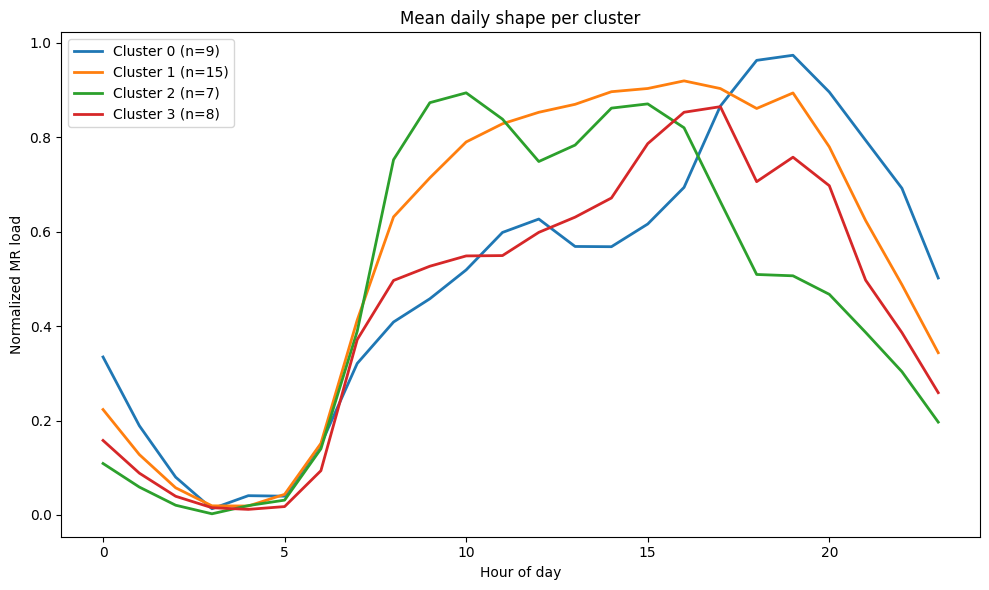

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for c in sorted(set(labels)):
    members = [cell for cell, lbl in zip(micro_cells, labels) if lbl == c]
    cluster_mean = profile_df.loc[members].mean(axis=0)
    ax.plot(range(24), cluster_mean, label=f'Cluster {c} (n={len(members)})', linewidth=2)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Normalized MR load')
ax.legend()
ax.set_title('Mean daily shape per cluster')
plt.tight_layout()
plt.show()